In [7]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf

import warnings
warnings.filterwarnings('ignore')

plt.style.use("ggplot")

In [8]:
df = pd.read_csv('/content/restaurant_sales_data.csv')

df.head()

,date,restaurant_id,restaurant_type,menu_item_name,meal_type,key_ingredients_tags,typical_ingredient_cost,observed_market_price,actual_selling_price,quantity_sold,has_promotion,special_event,weather_condition
0,1/1/2024,11,Food Stall,Laksa,Lunch,"rice noodles, fish broth, tamarind, shrimp pas...",4.5,10.59,12.48,361,False,False,Sunny
1,1/1/2024,7,Casual Dining,Spaghetti Carbonara,Dinner,"spaghetti, eggs, cheese, beef bacon, black pepper",9.0,26.64,60.46,105,False,False,Sunny
2,1/1/2024,23,Fine Dining,Beef Rendang,Dinner,"beef, coconut milk, galangal, lemongrass, spic...",9.0,49.42,80.15,36,False,False,Rainy
3,1/1/2024,22,Food Stall,Roti Canai,Dinner,"flour, ghee, egg, water, curry",0.8,2.04,2.48,503,False,False,Sunny
4,1/1/2024,32,Fine Dining,Spaghetti Carbonara,Lunch,"spaghetti, eggs, cheese, beef bacon, black pepper",9.0,40.30,55.54,262,False,False,Rainy


In [9]:
print("Shape :", df.shape)

print("\nColumns\n")
print(df.columns)

print("\nInformation\n")
df.info()

print("\nMissing Values\n")
print(df.isnull().sum())

Shape : (10000, 13)

Columns

Index(['date', 'restaurant_id', 'restaurant_type', 'menu_item_name',
       'meal_type', 'key_ingredients_tags', 'typical_ingredient_cost',
       'observed_market_price', 'actual_selling_price', 'quantity_sold',
       'has_promotion', 'special_event', 'weather_condition'],
      dtype='object')

Information

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   date                     10000 non-null  object 
 1   restaurant_id            10000 non-null  int64  
 2   restaurant_type          10000 non-null  object 
 3   menu_item_name           10000 non-null  object 
 4   meal_type                10000 non-null  object 
 5   key_ingredients_tags     10000 non-null  object 
 6   typical_ingredient_cost  10000 non-null  float64
 7   observed_market_price    10000 non-null  float64
 8   actua

In [10]:
df.columns = df.columns.str.strip().str.replace(" ", "_")

df.columns

Index(['date', 'restaurant_id', 'restaurant_type', 'menu_item_name',
       'meal_type', 'key_ingredients_tags', 'typical_ingredient_cost',
       'observed_market_price', 'actual_selling_price', 'quantity_sold',
       'has_promotion', 'special_event', 'weather_condition'],
      dtype='object')

In [13]:
df["date"] = pd.to_datetime(df["date"])

df = df.sort_values("date")

In [15]:
print("Restaurants :", df["restaurant_id"].nunique())

print("Menu Items :", df["menu_item_name"].nunique())

print("Restaurant Types :", df["restaurant_type"].unique())

Restaurants : 50
Menu Items : 14
Restaurant Types : ['Food Stall' 'Cafe' 'Fine Dining' 'Casual Dining' 'Kopitiam']


In [17]:
daily_sales = (
    df.groupby("date")["quantity_sold"]
      .sum()
      .reset_index()
)

daily_sales.head()

,date,quantity_sold
0,2024-01-01,8479
1,2024-01-02,7647
2,2024-01-03,4172
3,2024-01-04,7592
4,2024-01-05,6712


In [19]:
daily_sales.set_index("date", inplace=True)

daily_sales = daily_sales.asfreq("D")

daily_sales["quantity_sold"] = daily_sales["quantity_sold"].fillna(0)

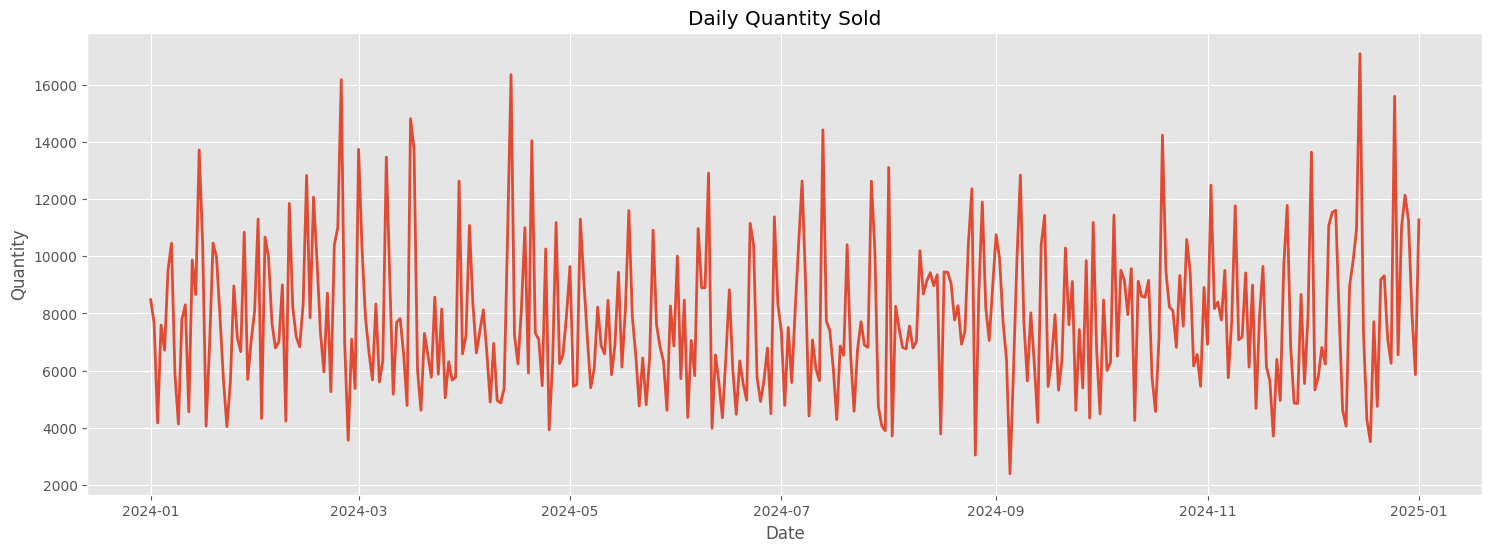

In [21]:
plt.figure(figsize=(18,6))

plt.plot(
    daily_sales.index,
    daily_sales["quantity_sold"],
    linewidth=2
)

plt.title("Daily Quantity Sold")

plt.xlabel("Date")

plt.ylabel("Quantity")

plt.show()

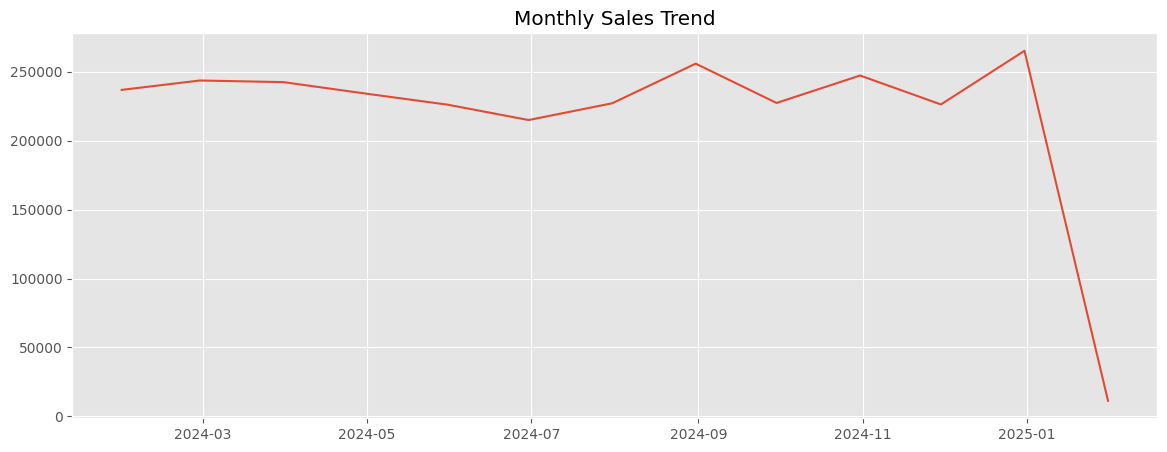

In [23]:
monthly = daily_sales.resample("M").sum()

plt.figure(figsize=(14,5))

plt.plot(monthly.index, monthly["quantity_sold"])

plt.title("Monthly Sales Trend")

plt.show()

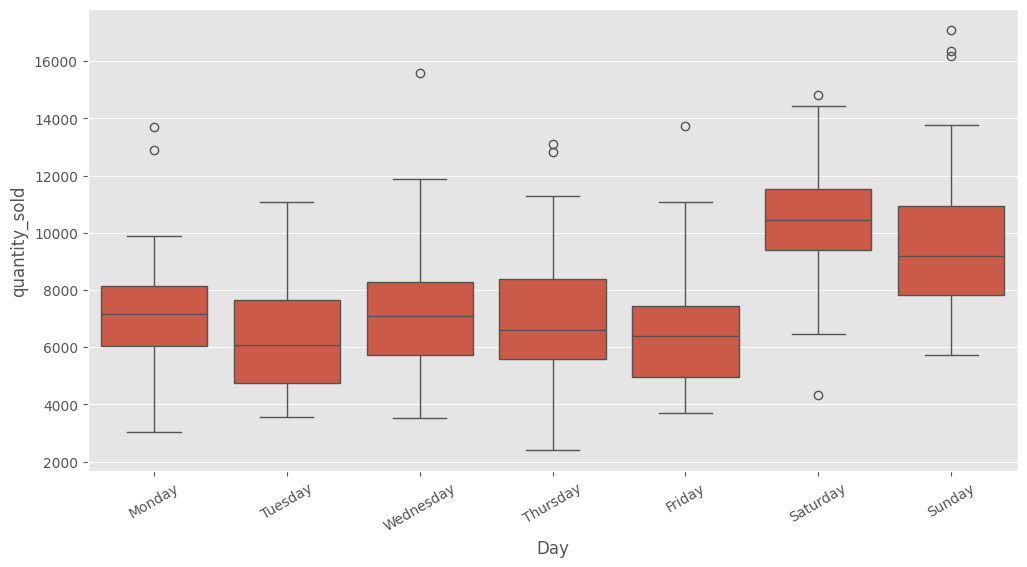

In [25]:
daily_sales["Day"] = daily_sales.index.day_name()

order = [
    "Monday","Tuesday","Wednesday",
    "Thursday","Friday","Saturday","Sunday"
]

plt.figure(figsize=(12,6))

sns.boxplot(
    data=daily_sales,
    x="Day",
    y="quantity_sold",
    order=order
)

plt.xticks(rotation=30)

plt.show()

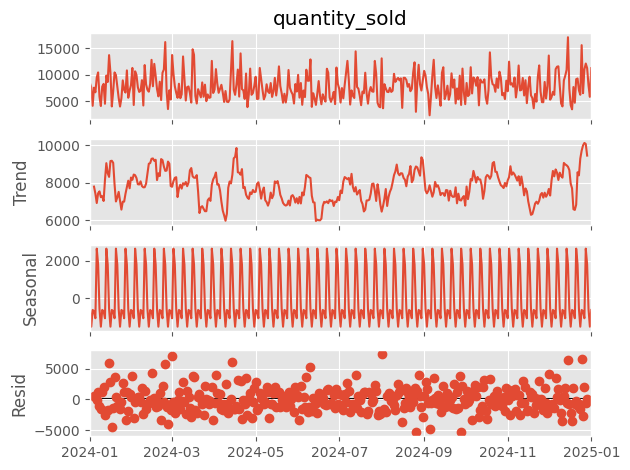

In [28]:
decomposition = seasonal_decompose(
    daily_sales["quantity_sold"],
    model="additive",
    period=7
)

decomposition.plot()

plt.show()

<Figure size 1200x500 with 0 Axes>

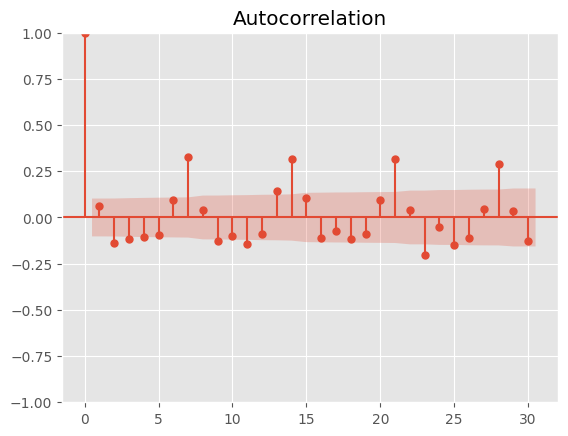

In [29]:
plt.figure(figsize=(12,5))

plot_acf(
    daily_sales["quantity_sold"],
    lags=30
)

plt.show()

In [31]:
Q1 = daily_sales["quantity_sold"].quantile(0.25)

Q3 = daily_sales["quantity_sold"].quantile(0.75)

IQR = Q3-Q1

lower = Q1-1.5*IQR

upper = Q3+1.5*IQR

outliers = daily_sales[
    (daily_sales["quantity_sold"]<lower) |
    (daily_sales["quantity_sold"]>upper)
]

print(outliers)

            quantity_sold        Day
date                                
2024-02-25          16173     Sunday
2024-03-16          14811   Saturday
2024-04-14          16350     Sunday
2024-12-15          17081     Sunday
2024-12-25          15591  Wednesday


In [35]:
daily_sales.to_csv("processed_sales.csv")